# Problem Komiwojażera (TSP)

**Przedmiot:** Algorytmy Optymalizacji Dyskretnej  

**Temat:** Traveling Salesman Problem 

**Autor:** Sebastian Świderek 263330


In [1]:
# ─── 1. Importy ───────────────────────────────────────────────────────────────
import itertools
import time
import math
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from queue import PriorityQueue


In [2]:
# ─── 2. Klasy z laboratoriów (Graph, WeightedGraph) ──────────────────────────

class Graph:
    """Reprezentacja grafu jako słownik sąsiedztwa — każdy wierzchołek ma listę sąsiadów."""

    def __init__(self, graph=None, directed=0):
        if graph is None:
            graph = {}
        self.graph = graph
        self.directed = directed

    @classmethod
    def from_dict(cls, graph):
        return cls(graph)
    def vertices(self):
        return list(self.graph.keys())
        
# dodaje wierzchołek jeśli jeszcze nie istnieje
    def add_vertex(self, vertex):
        if vertex not in self.graph:
            self.graph[vertex] = []
            
#przyjmuje parę wierzchołków i dodaje krawędź w obie strony — graf jest nieskierowany
    def add_edge(self, edge, weight=None):
        u, v = edge
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)
        if u not in self.graph[v]:
            self.graph[v].append(u)


class WeightedGraph(Graph):
    """Rozszerza graf o wagi krawędzi, czyli słownik gdzie para wierzchołków mapuje się na liczbę — odległość."""

    def __init__(self, graph=None, directed=0, weights=None):
        super().__init__(graph, directed)
        self.weights = weights if weights is not None else {}
        
    def add_edge(self, edge, weight=1):
        u, v = edge
        super().add_edge(edge)
        self.weights[(u, v)] = weight
        self.weights[(v, u)] = weight

    def get_weight(self, u, v):
        return self.weights.get((u, v), float('inf'))


In [3]:
# ─── 3. Klasa TSPGraph ────────────────────────────────────────────────────────

class TSPGraph(WeightedGraph):
    """
    Graf ważony przystosowany do TSP.
    Dziedziczy po WeightedGraph.

    Dodatkowe atrybuty:
      coords : słownik {wierzchołek: (x, y)}
    """

    def __init__(self, graph=None, directed=0, weights=None, coords=None):
        super().__init__(graph, directed, weights)
        self.coords = coords if coords is not None else {}

    # ── Fabryki ──────────────────────────────────────────────────────────

    @classmethod
    def from_coords(cls, coords: dict):
        """
        Metoda ta iteruje po wszystkich parach miast, liczy odległość euklidesową i dodaje krawędź z tą wagą.
        Wynik to pełny graf, każde miasto połączone z każdym.
        """
        g = cls(coords=dict(coords))
        cities = list(coords.keys())
        for i in range(len(cities)):
            for j in range(i + 1, len(cities)):
                u, v = cities[i], cities[j]
                x1, y1 = coords[u]
                x2, y2 = coords[v]
                dist = round(math.sqrt((x2-x1)**2 + (y2-y1)**2), 2)
                g.add_edge([u, v], dist)
        return g

    @classmethod
    def random_tsp(cls, n: int, seed_val: int = None, scale: int = 100):
        """
        Generuje n losowych punktów na kwadracie 100×100 i woła from_coords.
        Seed zapewnia powtarzalność — ten sam seed to zawsze te same miasta,
        ważne przy porównywaniu algorytmów.
        """
        if seed_val is not None:
            random.seed(seed_val)
        coords = {i: (random.uniform(0, scale), random.uniform(0, scale))
                  for i in range(n)}
        return cls.from_coords(coords)

    @classmethod
    def from_matrix(cls, dist_matrix, labels=None):
        """
        Tworzy graf z gotowej macierzy odległości.
        Przydatne w testach gdzie mam konkretne ręcznie policzone liczby.
        ”"""
        n = len(dist_matrix)
        if labels is None:
            labels = list(range(n))
        g = cls()
        for i in range(n):
            for j in range(i + 1, n):
                if dist_matrix[i][j] > 0:
                    g.add_edge([labels[i], labels[j]], dist_matrix[i][j])
        return g

    # ── Macierz odległości ───────────────────────────────────────────────

    def distance_matrix(self):
        """Zwraca (macierz numpy n×n, lista wierzchołków)."""
        vertices = self.vertices()
        n = len(vertices)
        idx = {v: i for i, v in enumerate(vertices)}
        matrix = np.full((n, n), float('inf'))
        np.fill_diagonal(matrix, 0)
        for (u, v), w in self.weights.items():
            matrix[idx[u]][idx[v]] = w
        return matrix, vertices

    # ── Koszt trasy ──────────────────────────────────────────────────────

    def tour_cost(self, tour: list) -> float:
        """
        Oblicza łączny koszt cyklu Hamiltona.
        
        Iteruje po trasie, sumuje wagi kolejnych krawędzi i domyka cykl — dodaje 
        krawędź z ostatniego miasta z powrotem do pierwszego. Jeśli jakaś krawędź 
        nie istnieje, zwraca nieskończoność. Każdy algorytm używa tej funkcji żeby 
        ocenić jakość trasy.”
        """
        cost = 0.0
        n = len(tour)
        for i in range(n):
            w = self.get_weight(tour[i], tour[(i+1) % n])
            if w == float('inf'):
                return float('inf')
            cost += w
        return cost

    # ── Wizualizacja ─────────────────────────────────────────────────────

    def plot_tour(self, tour: list, title: str = "Trasa komiwojażera",
                  cost: float = None, ax=None, color_tour='crimson',
                  show: bool = True, show_weights: bool = True):
        """Rysuje graf z zaznaczoną trasą."""
        if not self.coords:
            G = nx.Graph(self.graph)
            pos = nx.spring_layout(G, seed=42)
        else:
            pos = {v: self.coords[v] for v in self.graph}

        if ax is None:
            fig, ax = plt.subplots(figsize=(9, 7))

        G = nx.Graph(self.graph)

        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.08,
                               edge_color='gray', width=1)

        tour_edges = [(tour[i], tour[(i+1) % len(tour)])
                      for i in range(len(tour))]
        nx.draw_networkx_edges(G, pos, edgelist=tour_edges, ax=ax,
                               edge_color=color_tour, width=3.0, alpha=0.9)

        if show_weights:
            tour_edge_labels = {}
            for i in range(len(tour)):
                u = tour[i]
                v = tour[(i + 1) % len(tour)]
                w = self.get_weight(u, v)
                if w != float('inf'):
                    tour_edge_labels[(u, v)] = f"{w:.1f}"
            nx.draw_networkx_edge_labels(
                G, pos,
                edge_labels=tour_edge_labels,
                ax=ax,
                font_size=8,
                font_color='darkred',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7),
                label_pos=0.35
            )

        nx.draw_networkx_nodes(G, pos, ax=ax, node_color='steelblue',
                               node_size=600)
        nx.draw_networkx_labels(G, pos, ax=ax,
                                font_color='black', font_weight='bold', font_size=11)

        for i, v in enumerate(tour):
            x, y = pos[v]
            ax.annotate(
                f"{i+1}.",
                (x, y),
                xytext=(12, 12),
                textcoords='offset points',
                fontsize=9,
                color='navy',
                fontweight='bold'
            )

        full_title = title
        if cost is not None:
            full_title += f"\nŁączny koszt trasy: {cost:.2f}"
        ax.set_title(full_title, fontsize=13, fontweight='bold')
        ax.axis('off')

        if show:
            plt.tight_layout()
            plt.show()


In [4]:
# ─── 4. Algorytmy TSP ─────────────────────────────────────────────────────────

def brute_force(graph: TSPGraph, start=None):
    """
    Sprawdza wszystkie (n-1)! permutacje pozostałych wierzchołków.
    Gwarantuje optimum – praktyczny tylko do n≤10.
    Złożoność: O(n!)
    """
    t0 = time.perf_counter()
    vertices = graph.vertices()
    n = len(vertices)
    if start is None:
        start = vertices[0]

    others = [v for v in vertices if v != start]
    best_tour, best_cost = None, float('inf')

    for perm in itertools.permutations(others):
        tour = [start] + list(perm)
        cost = graph.tour_cost(tour)
        if cost < best_cost:
            best_cost = cost
            best_tour = tour

    return {'tour': best_tour, 'cost': best_cost,
            'time': time.perf_counter() - t0}


def nearest_neighbour(graph: TSPGraph, start=None):
    """
    Algorytm zachłanny: zawsze idź do najbliższego nieodwiedzonego miasta.
    Złożoność: O(n²)
    """
    t0 = time.perf_counter()
    vertices = graph.vertices()
    if start is None:
        start = vertices[0]

    unvisited = set(vertices)
    unvisited.discard(start)
    tour = [start]
    current = start

    while unvisited:
        best_next = min(unvisited, key=lambda v: graph.get_weight(current, v))
        tour.append(best_next)
        unvisited.discard(best_next)
        current = best_next

    return {'tour': tour, 'cost': graph.tour_cost(tour),
            'time': time.perf_counter() - t0}



def held_karp(graph: TSPGraph, start=None):
    """
    Held-Karp: dokładny algorytm TSP – programowanie dynamiczne na podzbiorach.
    Złożoność: O(n² · 2ⁿ) czasowa, O(n · 2ⁿ) pamięciowa
    """
    t0 = time.perf_counter()
    vertices = graph.vertices()
    n = len(vertices)
    if start is None:
        start = vertices[0]

    if start != vertices[0]:
        s_idx = vertices.index(start)
        vertices[0], vertices[s_idx] = vertices[s_idx], vertices[0]
    idx_of = {v: i for i, v in enumerate(vertices)}

    dist = np.full((n, n), float('inf'))
    np.fill_diagonal(dist, 0)
    for (u, v), w in graph.weights.items():
        dist[idx_of[u]][idx_of[v]] = w

    INF = float('inf')
    total_masks = 1 << n
    dp   = [[INF] * n for _ in range(total_masks)]
    prev = [[-1]  * n for _ in range(total_masks)]
    dp[1][0] = 0

    for mask in range(1, total_masks):
        if not (mask & 1):
            continue
        for v in range(n):
            if not (mask >> v & 1):
                continue
            if dp[mask][v] == INF:
                continue
            for u in range(n):
                if mask >> u & 1:
                    continue
                new_mask = mask | (1 << u)
                new_cost = dp[mask][v] + dist[v][u]
                if new_cost < dp[new_mask][u]:
                    dp[new_mask][u] = new_cost
                    prev[new_mask][u] = v

    full_mask = total_masks - 1
    best_cost, last = INF, -1
    for v in range(1, n):
        c = dp[full_mask][v] + dist[v][0]
        if c < best_cost:
            best_cost, last = c, v

    tour_idx, mask, cur = [], full_mask, last
    while cur != -1:
        tour_idx.append(cur)
        nxt = prev[mask][cur]
        mask ^= (1 << cur)
        cur = nxt
    tour_idx.reverse()
    tour = [vertices[i] for i in tour_idx]

    return {'tour': tour, 'cost': best_cost,
            'time': time.perf_counter() - t0}


def two_opt(graph: TSPGraph, initial_tour: list = None,
            max_iterations: int = 1000):
    """
    2-opt: zamienia pary krawędzi, jeśli daje to poprawę.
    Złożoność: O(n²) na iterację.
    """
    t0 = time.perf_counter()
    vertices = graph.vertices()
    n = len(vertices)

    if initial_tour is None:
        tour = nearest_neighbour(graph)['tour'][:]
    else:
        tour = list(initial_tour)

    improved, iterations = True, 0
    while improved and iterations < max_iterations:
        improved = False
        iterations += 1
        for i in range(n - 1):
            for k in range(i + 2, n):
                a, b = tour[i],     tour[i + 1]
                c, d = tour[k],     tour[(k + 1) % n]
                d1 = graph.get_weight(a, b) + graph.get_weight(c, d)
                d2 = graph.get_weight(a, c) + graph.get_weight(b, d)
                if d2 < d1 - 1e-10:
                    tour[i+1:k+1] = tour[i+1:k+1][::-1]
                    improved = True

    return {'tour': tour, 'cost': graph.tour_cost(tour),
            'time': time.perf_counter() - t0, 'iterations': iterations}


def nn_two_opt(graph: TSPGraph, start=None):
    """Pipeline: Nearest Neighbour → 2-opt."""
    nn = nearest_neighbour(graph, start=start)
    return two_opt(graph, initial_tour=nn['tour'])


Macierz odległości (zaokrąglona do 2 miejsc):
           A       B       C       D       E
  A    0.00    5.00    8.00    7.21    3.61
  B    5.00    0.00    5.00    7.28    6.32
  C    8.00    5.00    0.00    4.47    6.71
  D    7.21    7.28    4.47    0.00    4.12
  E    3.61    6.32    6.71    4.12    0.00
  Nearest Neighbour startuje z miasta A

Krok 1: jesteśmy w mieście A
  odl. do B = 5.00
  odl. do C = 8.00
  odl. do D = 7.21
  odl. do E = 3.61  ◄ WYBIERAMY

Krok 2: jesteśmy w mieście E
  odl. do B = 6.32
  odl. do C = 6.71
  odl. do D = 4.12  ◄ WYBIERAMY

Krok 3: jesteśmy w mieście D
  odl. do B = 7.28
  odl. do C = 4.47  ◄ WYBIERAMY

Krok 4: jesteśmy w mieście C
  odl. do B = 5.00  ◄ WYBIERAMY

Krok 5: wracamy z B do A: 5.00

Otrzymana trasa: A → E → D → C → B → A
Łączny koszt:    22.20

--- Porównanie algorytmów ---
  Brute Force                koszt=22.2000  czas=0.082 ms  trasa=['A', 'B', 'C', 'D', 'E']
  Nearest Neighbour          koszt=22.2000  czas=0.013 ms  trasa=['A',

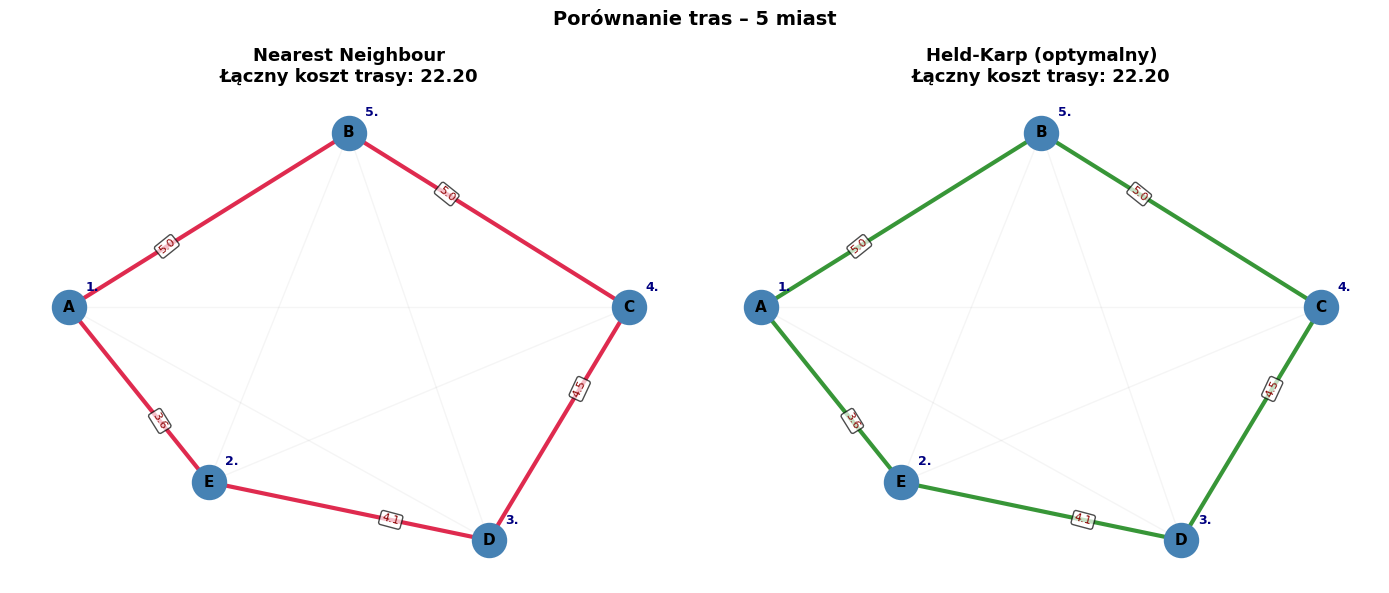

In [5]:
# ─── 5. Demo 5 miast ──────────────────────────────────────────────────────────

coords = {
    'A': (0, 0),
    'B': (4, 3),
    'C': (8, 0),
    'D': (6, -4),
    'E': (2, -3),
}
g5 = TSPGraph.from_coords(coords)

matrix, verts = g5.distance_matrix()
print("Macierz odległości (zaokrąglona do 2 miejsc):")
header = "      " + "  ".join(f"{v:>6}" for v in verts)
print(header)
for i, v in enumerate(verts):
    row = f"  {v}  " + "  ".join(f"{matrix[i][j]:>6.2f}" for j in range(len(verts)))
    print(row)

print("=" * 55)
print("  Nearest Neighbour startuje z miasta A")
print("=" * 55)

start = 'A'
unvisited = {'B', 'C', 'D', 'E'}
tour = [start]
current = start

for step in range(1, 5):
    distances = {v: g5.get_weight(current, v) for v in unvisited}
    nearest = min(distances, key=distances.get)
    print(f"\nKrok {step}: jesteśmy w mieście {current}")
    for v in sorted(distances):
        tag = "  ◄ WYBIERAMY" if v == nearest else ""
        print(f"  odl. do {v} = {distances[v]:.2f}{tag}")
    tour.append(nearest)
    unvisited.discard(nearest)
    current = nearest

ret = g5.get_weight(current, start)
print(f"\nKrok 5: wracamy z {current} do {start}: {ret:.2f}")
cost_nn = g5.tour_cost(tour)
print(f"\nOtrzymana trasa: {' → '.join(tour)} → {tour[0]}")
print(f"Łączny koszt:    {cost_nn:.2f}")

print("\n--- Porównanie algorytmów ---")
algos = {
    'Brute Force':       brute_force,
    'Nearest Neighbour': nearest_neighbour,
    'Held-Karp (DP)':   held_karp,
    'NN + 2-opt':        nn_two_opt,
}
results5 = {}
for name, fn in algos.items():
    r = fn(g5)
    results5[name] = r
    print(f"  {name:25s}  koszt={r['cost']:.4f}  czas={r['time']*1000:.3f} ms  trasa={r['tour']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
nn_r = results5['Nearest Neighbour']
hk_r = results5['Held-Karp (DP)']
g5.plot_tour(nn_r['tour'], title="Nearest Neighbour",
             cost=nn_r['cost'], ax=axes[0], show=False)
g5.plot_tour(hk_r['tour'], title="Held-Karp (optymalny)",
             cost=hk_r['cost'], ax=axes[1], color_tour='forestgreen', show=False)
plt.suptitle("Porównanie tras – 5 miast", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Nearest Neighbour : koszt = 423.44
NN + 2-opt        : koszt = 418.64
Poprawa           : 1.1%


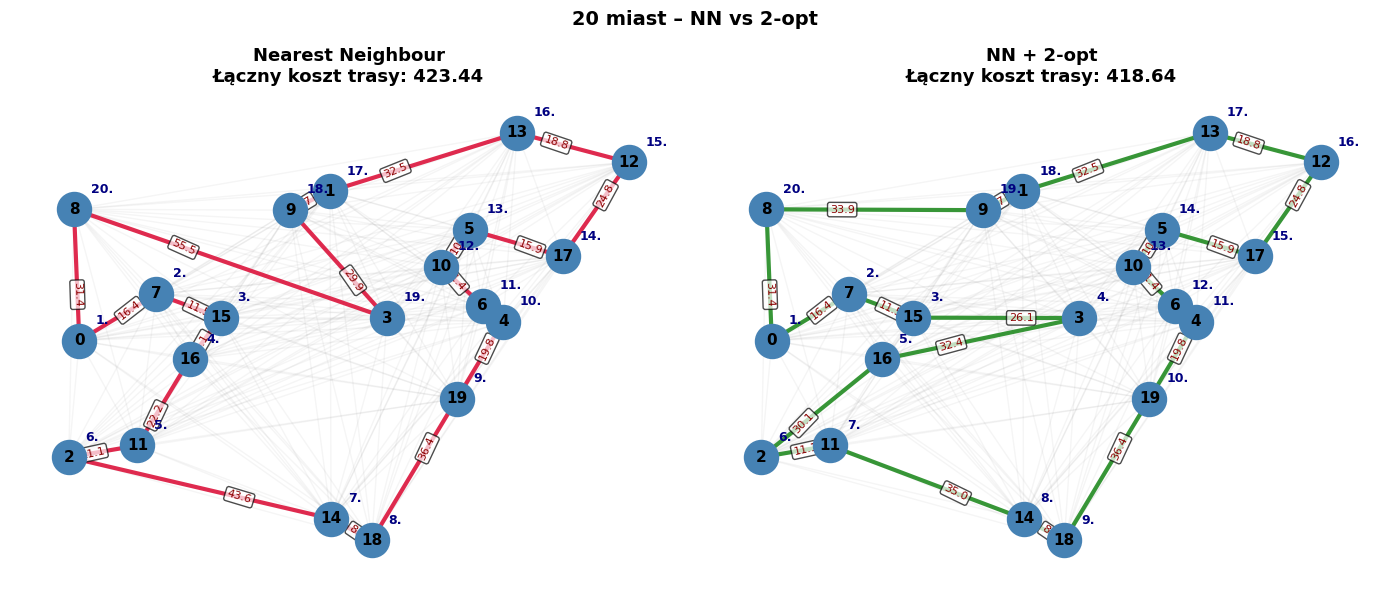

In [6]:
# ─── 6. Większa instancja – 20 miast ─────────────────────────────────────────

g20 = TSPGraph.random_tsp(20, seed_val=2026)

nn20  = nearest_neighbour(g20)
opt20 = nn_two_opt(g20)

print(f"Nearest Neighbour : koszt = {nn20['cost']:.2f}")
print(f"NN + 2-opt        : koszt = {opt20['cost']:.2f}")
print(f"Poprawa           : {(1 - opt20['cost']/nn20['cost'])*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
g20.plot_tour(nn20['tour'],  title="Nearest Neighbour",
              cost=nn20['cost'],  ax=axes[0], show=False)
g20.plot_tour(opt20['tour'], title="NN + 2-opt",
              cost=opt20['cost'], ax=axes[1],
              color_tour='forestgreen', show=False)
plt.suptitle("20 miast – NN vs 2-opt", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
# ─── 7. Testy jednostkowe ─────────────────────────────────────────────────────

def test(name, condition, info=""):
    status = "✓ OK  " if condition else "✗ FAIL"
    print(f"  [{status}]  {name}" + (f"  → {info}" if info else ""))
    return condition

print("=== Test 1: tour_cost ===")
g = TSPGraph()
for e in [(0,1),(1,2),(0,2)]: g.add_edge(e, 1.0)
test("Trójkąt [0,1,2]: koszt = 3.0", abs(g.tour_cost([0,1,2]) - 3.0) < 1e-9)
test("Trójkąt [0,2,1]: koszt = 3.0", abs(g.tour_cost([0,2,1]) - 3.0) < 1e-9)
test("Nieistniejąca krawędź → inf",   g.tour_cost([0,1,99]) == float('inf'))

print("=== Test 2: Brute Force ===")
m = [[0,10,15,20],[10,0,9,10],[15,9,0,5],[20,10,5,0]]
g4 = TSPGraph.from_matrix(m)
r = brute_force(g4)
test(f"Koszt optymalny = 40", abs(r['cost'] - 40) < 1e-9, f"koszt={r['cost']}, trasa={r['tour']}")
test("Trasa zawiera 4 wierzchołki", len(r['tour']) == 4)
test("Brak duplikatów w trasie", len(set(r['tour'])) == 4)

print("=== Test 3: HK == BF ===")
for seed in [1, 2, 7, 42, 100, 200, 2026]:
    g = TSPGraph.random_tsp(7, seed_val=seed)
    bf = brute_force(g)
    hk = held_karp(g)
    diff = abs(hk['cost'] - bf['cost'])
    test(f"seed={seed:4d}: HK ≈ BF", diff < 1e-6,
         f"HK={hk['cost']:.4f}  BF={bf['cost']:.4f}  diff={diff:.2e}")

print("=== Test 4: Nearest Neighbour ===")
for n in [5, 10, 20]:
    g = TSPGraph.random_tsp(n, seed_val=42)
    r = nearest_neighbour(g)
    verts = set(g.vertices())
    test(f"n={n:2d}: wszystkie wierzchołki odwiedzone", set(r['tour']) == verts)
    test(f"n={n:2d}: długość trasy = n",               len(r['tour']) == n)
    test(f"n={n:2d}: brak duplikatów",                 len(set(r['tour'])) == n)
    test(f"n={n:2d}: koszt spójny z tour_cost",        abs(r['cost'] - g.tour_cost(r['tour'])) < 1e-9)

print("=== Test 5: 2-opt ≤ NN ===")
for seed in [1, 5, 10, 42, 100, 200, 999]:
    g = TSPGraph.random_tsp(15, seed_val=seed)
    nn  = nearest_neighbour(g)
    opt = two_opt(g, initial_tour=nn['tour'])
    test(f"seed={seed:3d}: 2-opt ≤ NN",
         opt['cost'] <= nn['cost'] + 1e-9,
         f"NN={nn['cost']:.2f}  2opt={opt['cost']:.2f}")


=== Test 1: tour_cost ===
  [✓ OK  ]  Trójkąt [0,1,2]: koszt = 3.0
  [✓ OK  ]  Trójkąt [0,2,1]: koszt = 3.0
  [✓ OK  ]  Nieistniejąca krawędź → inf
=== Test 2: Brute Force ===
  [✓ OK  ]  Koszt optymalny = 40  → koszt=40.0, trasa=[0, 1, 3, 2]
  [✓ OK  ]  Trasa zawiera 4 wierzchołki
  [✓ OK  ]  Brak duplikatów w trasie
=== Test 3: HK == BF ===
  [✓ OK  ]  seed=   1: HK ≈ BF  → HK=315.4200  BF=315.4200  diff=0.00e+00
  [✓ OK  ]  seed=   2: HK ≈ BF  → HK=265.6100  BF=265.6100  diff=0.00e+00
  [✓ OK  ]  seed=   7: HK ≈ BF  → HK=229.4100  BF=229.4100  diff=0.00e+00
  [✓ OK  ]  seed=  42: HK ≈ BF  → HK=248.7500  BF=248.7500  diff=0.00e+00
  [✓ OK  ]  seed= 100: HK ≈ BF  → HK=254.6000  BF=254.6000  diff=0.00e+00
  [✓ OK  ]  seed= 200: HK ≈ BF  → HK=268.0100  BF=268.0100  diff=0.00e+00
  [✓ OK  ]  seed=2026: HK ≈ BF  → HK=206.3200  BF=206.3200  diff=0.00e+00
=== Test 4: Nearest Neighbour ===
  [✓ OK  ]  n= 5: wszystkie wierzchołki odwiedzone
  [✓ OK  ]  n= 5: długość trasy = n
  [✓ OK  ]  n= 5


Algorytm                        Koszt   Czas (ms)   vs. optimum
-----------------------------------------------------------------
Brute Force                  235.2800    1921.330  +    0.00%
Nearest Neighbour            235.2800       0.048  +    0.00%
Held-Karp (DP)               235.2800       7.279  +    0.00%
NN + 2-opt                   235.2800       0.056  +    0.00%


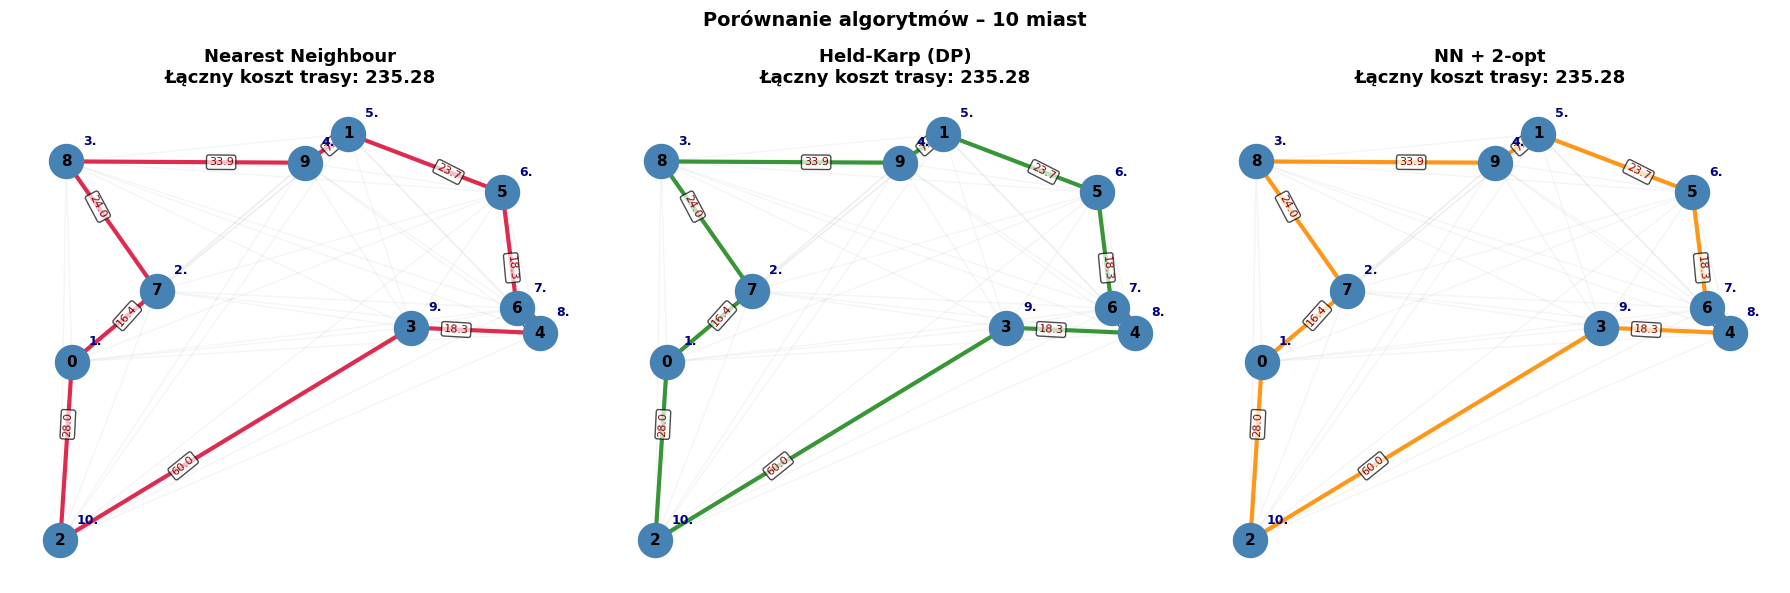

In [8]:
# ─── 8. Eksperymenty ──────────────────────────────────────────────────────────

# Eksperyment 1 – Jakość algorytmów (n=10)
g10 = TSPGraph.random_tsp(10, seed_val=2026)
algos_exp = {
    'Brute Force':       brute_force,
    'Nearest Neighbour': nearest_neighbour,
    'Held-Karp (DP)':   held_karp,
    'NN + 2-opt':        nn_two_opt,
}
print(f"\n{'Algorytm':25s}  {'Koszt':>10}  {'Czas (ms)':>10}  {'vs. optimum':>12}")
print("-" * 65)
results10 = {}
for name, fn in algos_exp.items():
    r = fn(g10)
    results10[name] = r

opt = results10['Held-Karp (DP)']['cost']
for name, r in results10.items():
    ratio = r['cost'] / opt
    print(f"{name:25s}  {r['cost']:>10.4f}  {r['time']*1000:>10.3f}  +{(ratio-1)*100:>8.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, color) in zip(axes, [
    ('Nearest Neighbour', 'crimson'),
    ('Held-Karp (DP)',    'forestgreen'),
    ('NN + 2-opt',        'darkorange'),
]):
    g10.plot_tour(results10[name]['tour'], title=name,
                  cost=results10[name]['cost'], ax=ax,
                  color_tour=color, show=False)
plt.suptitle("Porównanie algorytmów – 10 miast", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



  n     BF (ms)     HK (ms)     NN (ms)   2opt (ms)
--------------------------------------------------
  4       0.027       0.086      0.0120      0.0156
  5       0.078       0.088      0.0125      0.0243
  6       0.414       0.204      0.0175      0.0194
  7       6.249       0.594      0.0737      0.0372
  8      22.009       1.208      0.0250      0.0670
  9     195.682       3.035      0.0310      0.0821
 10    1889.533       7.157      0.0482      0.1014
 11   20676.849      17.270      0.0598      0.1312
 12           —      39.933      0.0710      0.2213
 13           —      94.815      0.0785      0.2680
 14           —     272.374      0.0966      0.3103
 15           —     523.254      0.1211      0.4312
 16           —    1325.106      0.1069      0.2931


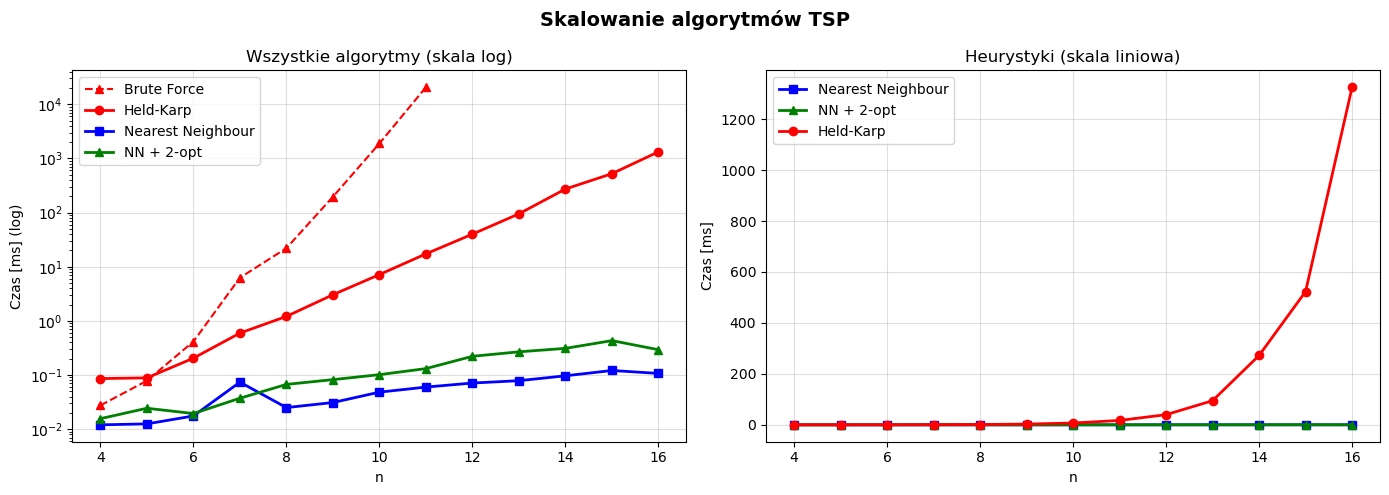

In [9]:

# Eksperyment 2 – Skalowanie czasu
sizes = list(range(4, 17))
t_bf, t_hk, t_nn, t_2o = [], [], [], []
print(f"\n{'n':>3}  {'BF (ms)':>10}  {'HK (ms)':>10}  {'NN (ms)':>10}  {'2opt (ms)':>10}")
print("-" * 50)
for n in sizes:
    g = TSPGraph.random_tsp(n, seed_val=7)
    rbf = brute_force(g)         if n <= 11 else None
    rhk = held_karp(g)
    rnn = nearest_neighbour(g)
    r2o = nn_two_opt(g)
    t_bf.append(rbf['time']*1000 if rbf else None)
    t_hk.append(rhk['time']*1000)
    t_nn.append(rnn['time']*1000)
    t_2o.append(r2o['time']*1000)
    bf_s = f"{rbf['time']*1000:>10.3f}" if rbf else f"{'—':>10}"
    print(f"{n:>3}  {bf_s}  {rhk['time']*1000:>10.3f}  {rnn['time']*1000:>10.4f}  {r2o['time']*1000:>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
valid_bf = [(s, t) for s, t in zip(sizes, t_bf) if t is not None]
axes[0].semilogy(*zip(*valid_bf), 'r^--', lw=1.5, label='Brute Force')
axes[0].semilogy(sizes, t_hk, 'ro-', lw=2, label='Held-Karp')
axes[0].semilogy(sizes, t_nn, 'bs-', lw=2, label='Nearest Neighbour')
axes[0].semilogy(sizes, t_2o, 'g^-', lw=2, label='NN + 2-opt')
axes[0].set(xlabel='n', ylabel='Czas [ms] (log)', title='Wszystkie algorytmy (skala log)')
axes[0].grid(alpha=0.4); axes[0].legend()
axes[1].plot(sizes, t_nn, 'bs-', lw=2, label='Nearest Neighbour')
axes[1].plot(sizes, t_2o, 'g^-', lw=2, label='NN + 2-opt')
axes[1].plot(sizes, t_hk, 'ro-', lw=2, label='Held-Karp')
axes[1].set(xlabel='n', ylabel='Czas [ms]', title='Heurystyki (skala liniowa)')
axes[1].grid(alpha=0.4); axes[1].legend()
plt.suptitle("Skalowanie algorytmów TSP", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()



  n   Śr. nadwyżka NN [%]       Min       Max
  5                  2.59%     0.00%    13.59%
  6                  3.50%     0.00%    15.24%
  7                  5.65%     0.00%    27.86%
  8                  6.17%     0.00%    21.58%
  9                  8.48%     0.00%    29.12%
 10                  8.41%     0.00%    29.36%
 11                 12.53%     0.00%    37.99%
 12                 12.38%     0.00%    39.47%


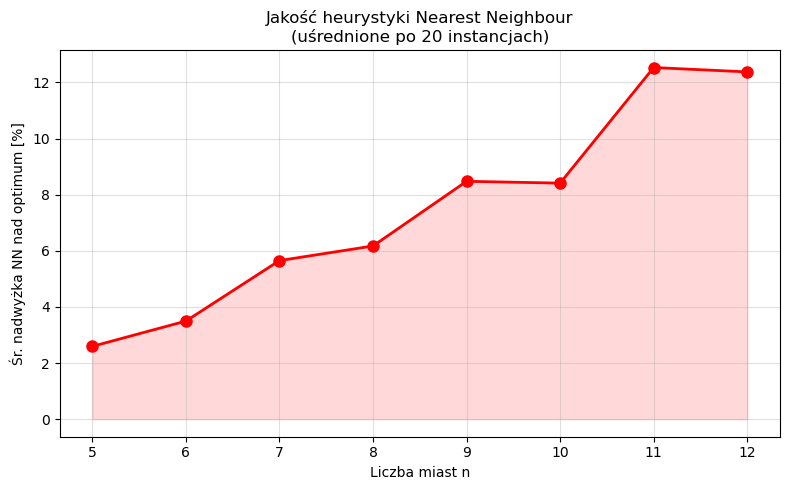

In [10]:
# Eksperyment 3 – Jakość NN statystycznie
sizes_q = list(range(5, 13))
avg_excess = []
n_trials = 20
print(f"\n{'n':>3}  {'Śr. nadwyżka NN [%]':>20}  {'Min':>8}  {'Max':>8}")
for n in sizes_q:
    ratios = []
    for seed in range(n_trials):
        g = TSPGraph.random_tsp(n, seed_val=seed)
        nn_c = nearest_neighbour(g)['cost']
        hk_c = held_karp(g)['cost']
        if hk_c > 0: ratios.append(nn_c / hk_c)
    avg = (sum(ratios)/len(ratios) - 1) * 100
    mn  = (min(ratios) - 1) * 100
    mx  = (max(ratios) - 1) * 100
    avg_excess.append(avg)
    print(f"{n:>3}  {avg:>20.2f}%  {mn:>7.2f}%  {mx:>7.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(sizes_q, avg_excess, 'ro-', lw=2, markersize=8)
plt.fill_between(sizes_q, [0]*len(sizes_q), avg_excess, alpha=0.15, color='red')
plt.xlabel("Liczba miast n"); plt.ylabel("Śr. nadwyżka NN nad optimum [%]")
plt.title(f"Jakość heurystyki Nearest Neighbour\n(uśrednione po {n_trials} instancjach)")
plt.grid(alpha=0.4); plt.tight_layout(); plt.show()




  n          NN       2-opt     Poprawa
 10      294.66      264.14      10.36%
 12      305.47      272.25      10.88%
 14      345.16      284.91      17.46%
 16      335.59      289.64      13.69%
 18      460.16      353.21      23.24%
 20      460.50      353.55      23.22%


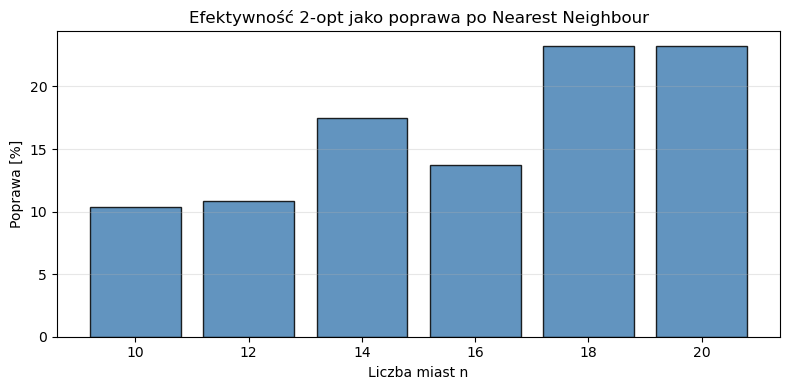

In [11]:
# Eksperyment 4 – Efekt 2-opt
sizes_v = [10, 12, 14, 16, 18, 20]
improvements = []
print(f"\n{'n':>3}  {'NN':>10}  {'2-opt':>10}  {'Poprawa':>10}")
for n in sizes_v:
    g = TSPGraph.random_tsp(n, seed_val=42)
    rnn  = nearest_neighbour(g)
    r2o  = nn_two_opt(g)
    imp  = (1 - r2o['cost']/rnn['cost']) * 100
    improvements.append(imp)
    print(f"{n:>3}  {rnn['cost']:>10.2f}  {r2o['cost']:>10.2f}  {imp:>9.2f}%")

plt.figure(figsize=(8, 4))
plt.bar([str(n) for n in sizes_v], improvements, color='steelblue', alpha=0.85, edgecolor='black')
plt.xlabel("Liczba miast n"); plt.ylabel("Poprawa [%]")
plt.title("Efektywność 2-opt jako poprawa po Nearest Neighbour")
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

=== Polska ===
Nearest Neighbour : 36.94
NN + 2-opt        : 27.30
Held-Karp         : 27.04

Optymalna trasa:
Warszawa → Łódź → Kraków → Katowice → Opole → Wrocław → Zielona Góra → Gorzów Wlkp. → Szczecin → Poznań → Bydgoszcz → Toruń → Gdańsk → Olsztyn → Białystok → Lublin → Rzeszów → Kielce → Radom → Warszawa


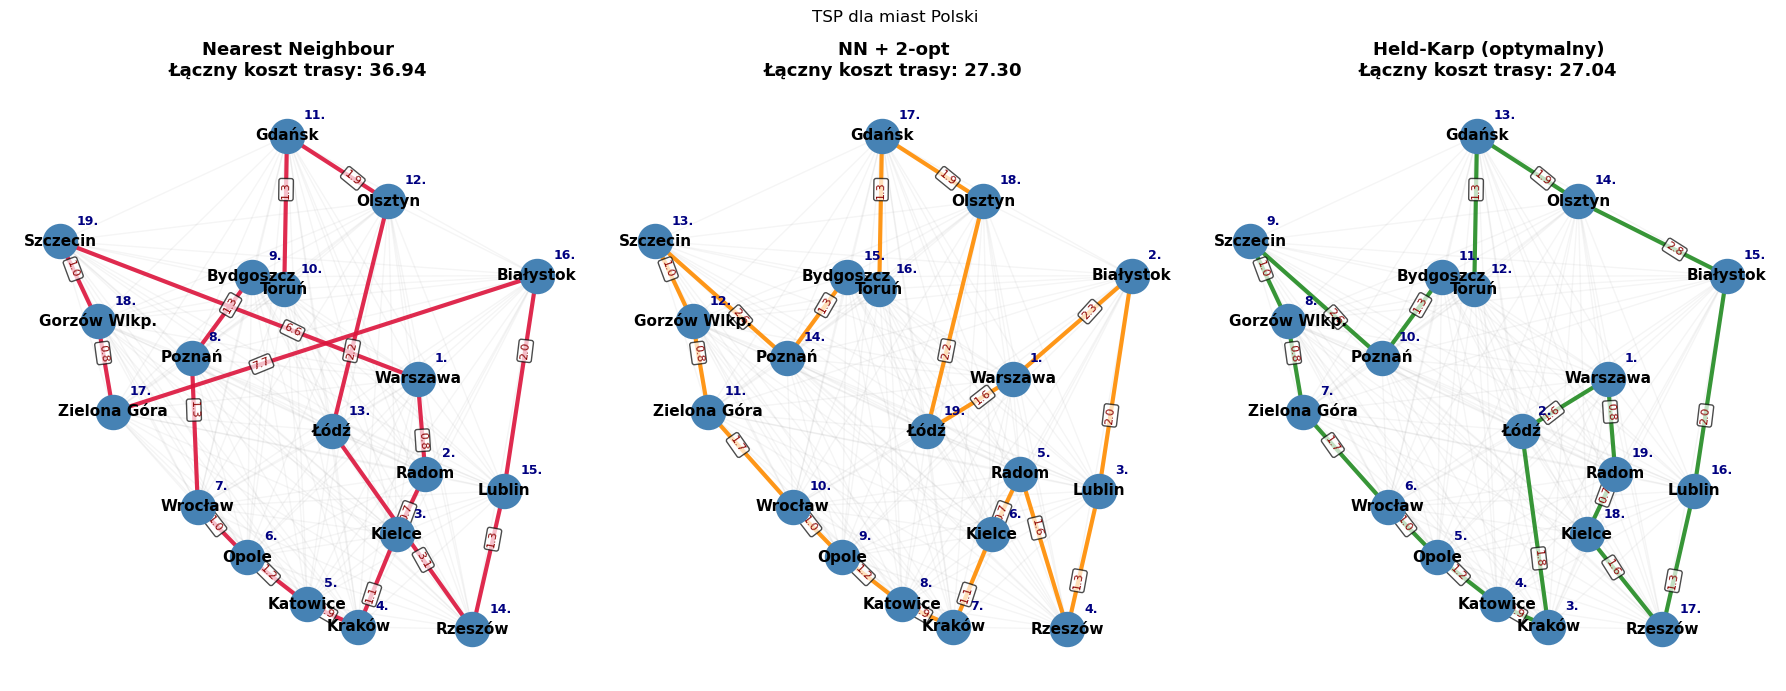

In [12]:
# ─── 9. BONUS: Polska ─────────────────────────────────────────────

poland_coords = {
    'Warszawa':  (21.01, 52.23),
    'Kraków':    (19.94, 50.06),
    'Gdańsk':    (18.65, 54.35),
    'Wrocław':   (17.04, 51.11),
    'Poznań':    (16.93, 52.41),
    'Łódź':      (19.46, 51.77),
    'Katowice':  (19.02, 50.26),
    'Lublin':    (22.57, 51.25),
    'Białystok': (23.16, 53.13),
    'Szczecin':  (14.55, 53.43),
    'Rzeszów':   (22.00, 50.04),
    'Bydgoszcz': (18.01, 53.12),
    'Toruń':        (18.60, 53.01),
    'Olsztyn':      (20.48, 53.78),
    'Zielona Góra': (15.51, 51.94),
    'Gorzów Wlkp.': (15.23, 52.73),
    'Opole':        (17.93, 50.67),
    'Kielce':       (20.63, 50.87),
    'Radom':        (21.15, 51.40),
}

g_poland = TSPGraph.from_coords(poland_coords)

nn = nearest_neighbour(g_poland, start='Warszawa')
opt = nn_two_opt(g_poland, start='Warszawa')
hk = held_karp(g_poland, start='Warszawa')

print("=== Polska ===")
print(f"Nearest Neighbour : {nn['cost']:.2f}")
print(f"NN + 2-opt        : {opt['cost']:.2f}")
print(f"Held-Karp         : {hk['cost']:.2f}")

print(f"\nOptymalna trasa:")
print(" → ".join(hk['tour']) + f" → {hk['tour'][0]}")

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

g_poland.plot_tour(
    nn['tour'],
    title="Nearest Neighbour",
    cost=nn['cost'],
    ax=axes[0],
    show=False
)

g_poland.plot_tour(
    opt['tour'],
    title="NN + 2-opt",
    cost=opt['cost'],
    ax=axes[1],
    color_tour='darkorange',
    show=False
)

g_poland.plot_tour(
    hk['tour'],
    title="Held-Karp (optymalny)",
    cost=hk['cost'],
    ax=axes[2],
    color_tour='forestgreen',
    show=False
)

plt.suptitle("TSP dla miast Polski")
plt.tight_layout()
plt.show()